# EDA

## Libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data loading

In [2]:
os.getcwd()

'/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/notebooks'

In [3]:
file_path = '../data/Base.csv'

In [5]:
df = pd.read_csv(file_path)
df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.8,0.124690,-1,143,30,0.051348,-0.826239,AB,530,...,0,1500.0,0,INTERNET,16.967770,other,0,1,0,7
999996,0,0.9,0.824544,-1,193,30,0.009591,0.008307,AC,408,...,1,1000.0,0,INTERNET,1.504109,macintosh,0,1,0,7
999997,0,0.8,0.140891,-1,202,10,0.059287,50.609995,AA,749,...,0,200.0,0,INTERNET,16.068595,other,0,1,0,7
999998,0,0.9,0.002480,52,3,30,0.023357,-1.313387,AB,707,...,0,200.0,0,INTERNET,1.378683,linux,1,1,0,7


In [14]:
df.columns

Index(['fraud_bool', 'income', 'name_email_similarity',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'employment_status',
       'credit_risk_score', 'email_is_free', 'housing_status',
       'phone_home_valid', 'phone_mobile_valid', 'bank_months_count',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source',
       'session_length_in_minutes', 'device_os', 'keep_alive_session',
       'device_distinct_emails_8w', 'device_fraud_count', 'month'],
      dtype='object')

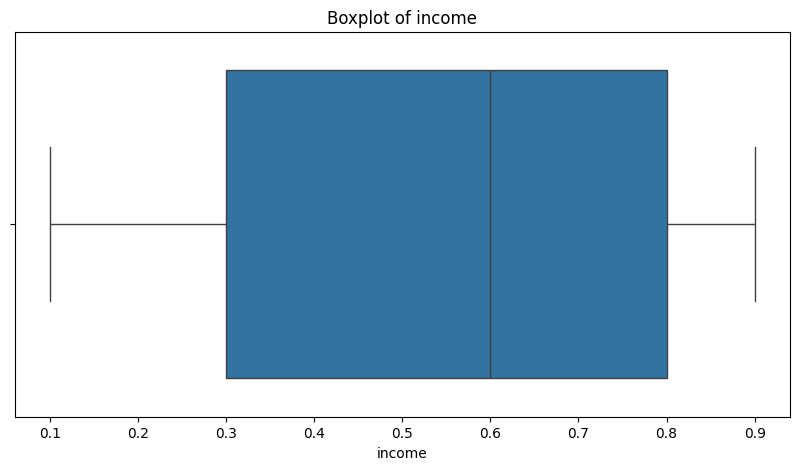

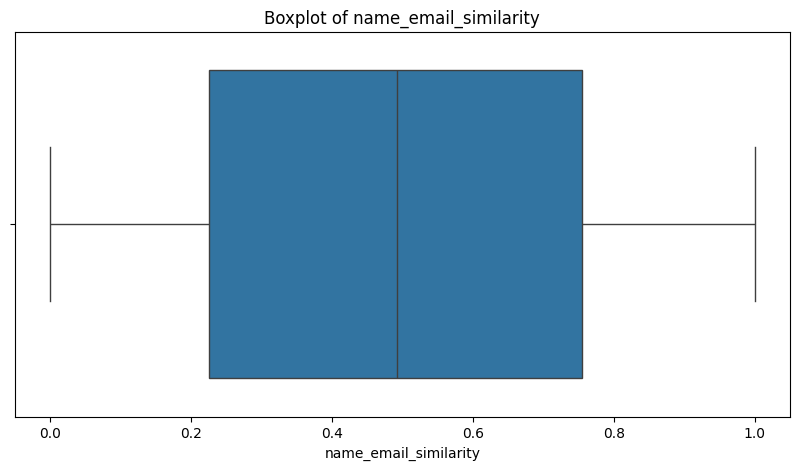

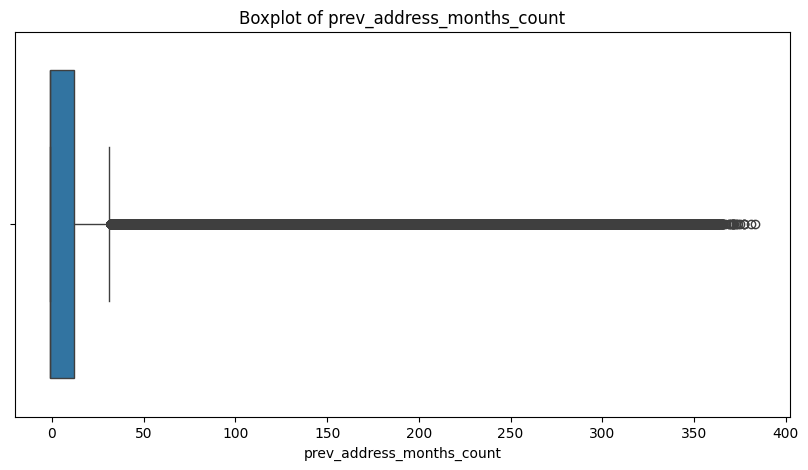

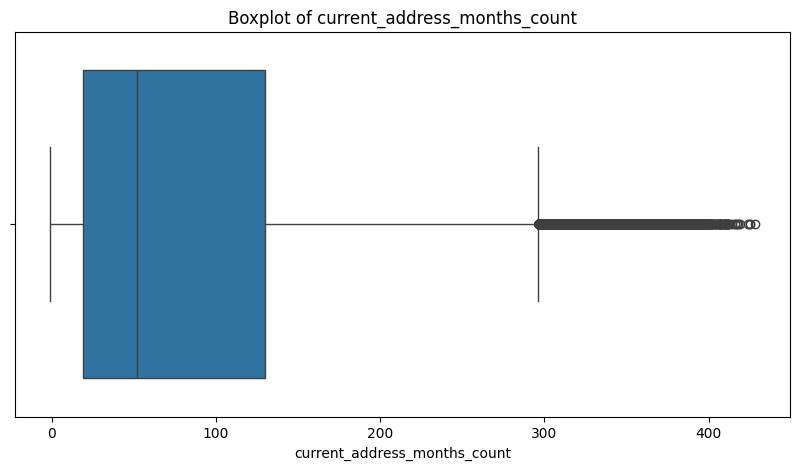

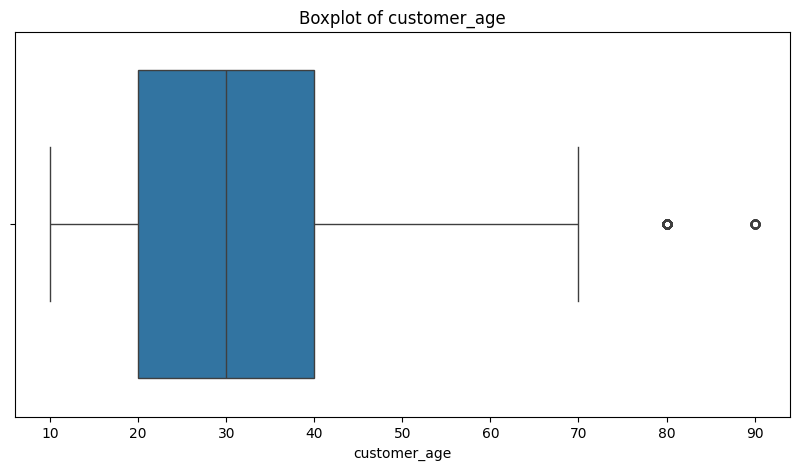

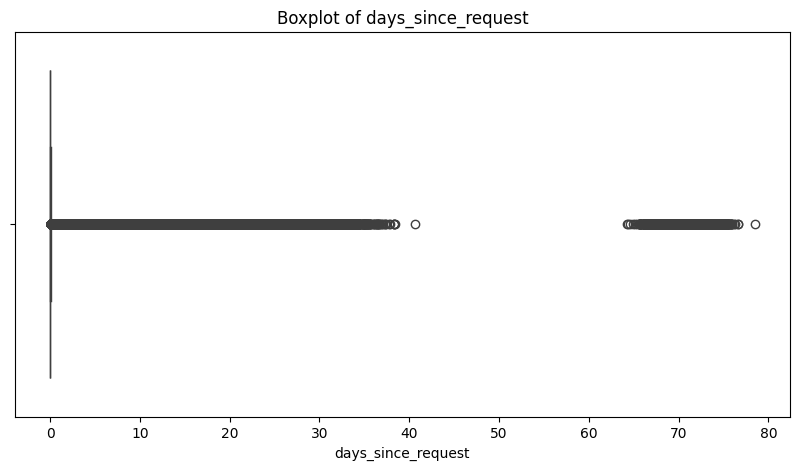

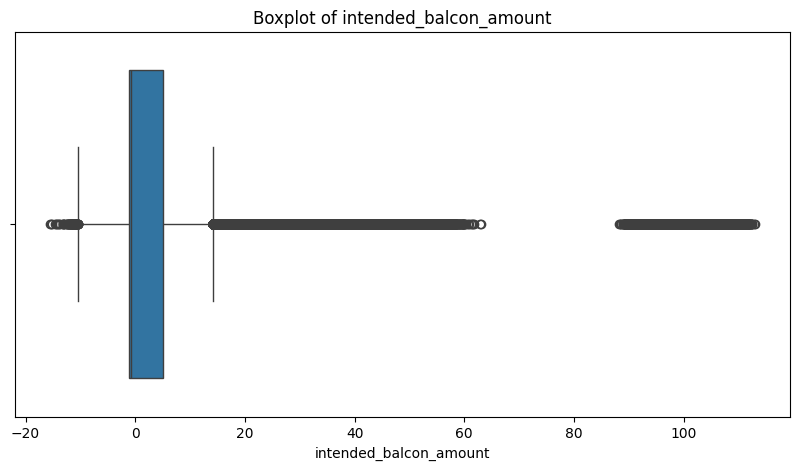

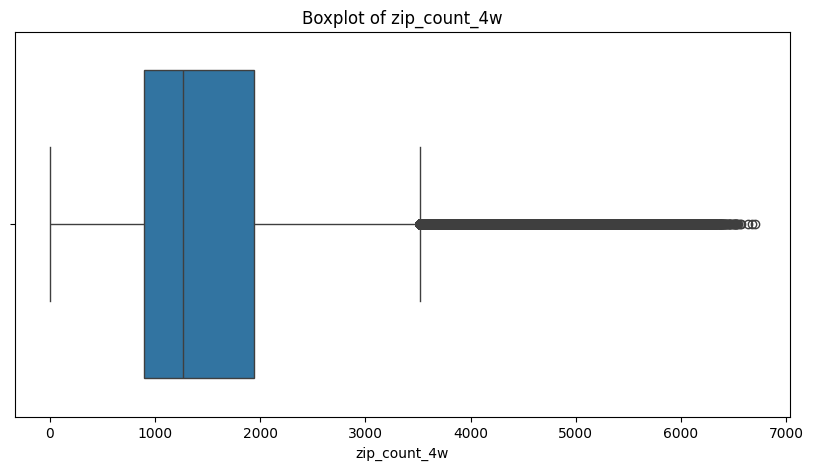

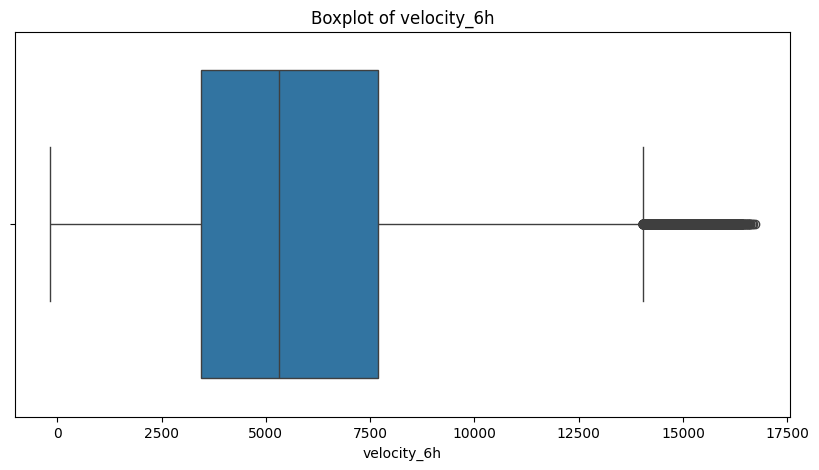

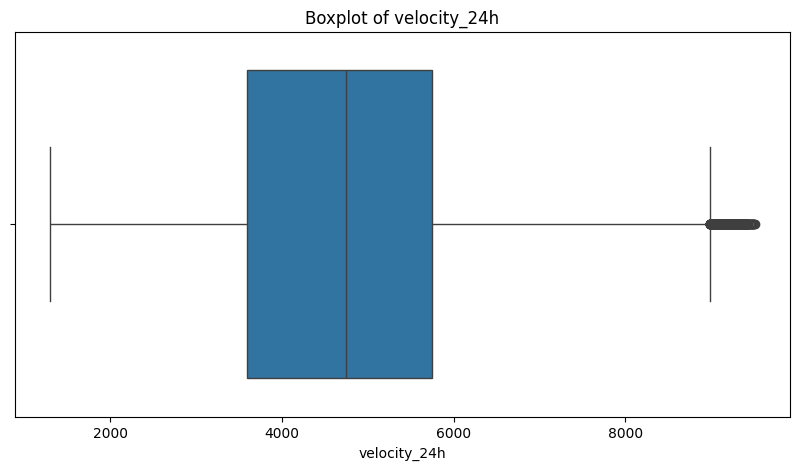

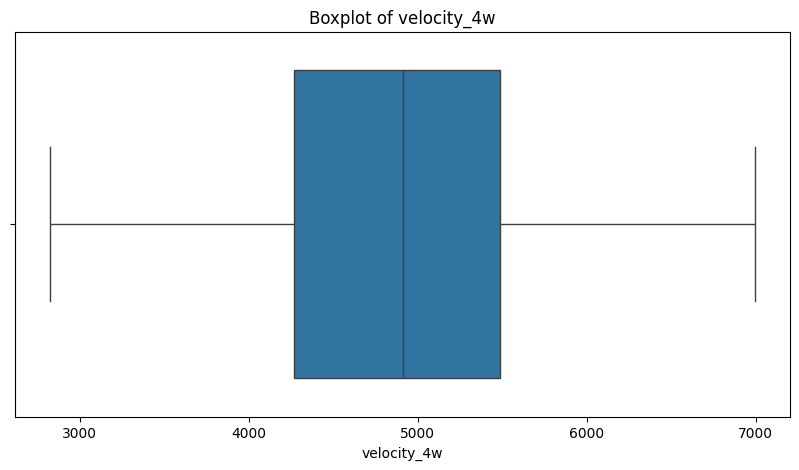

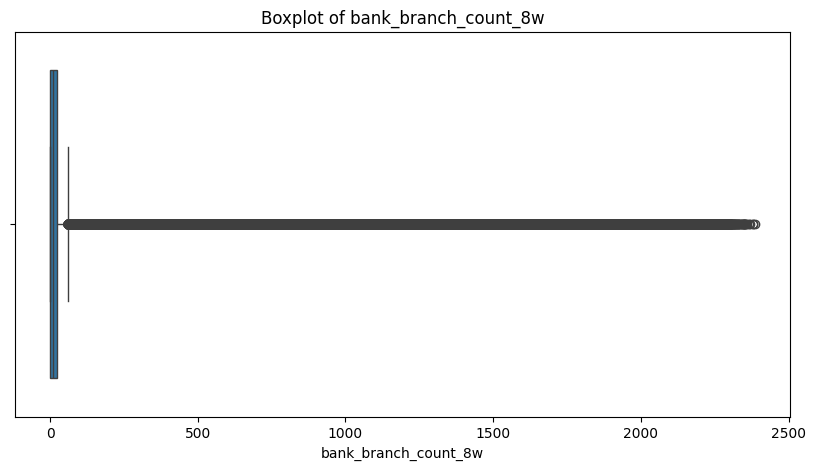

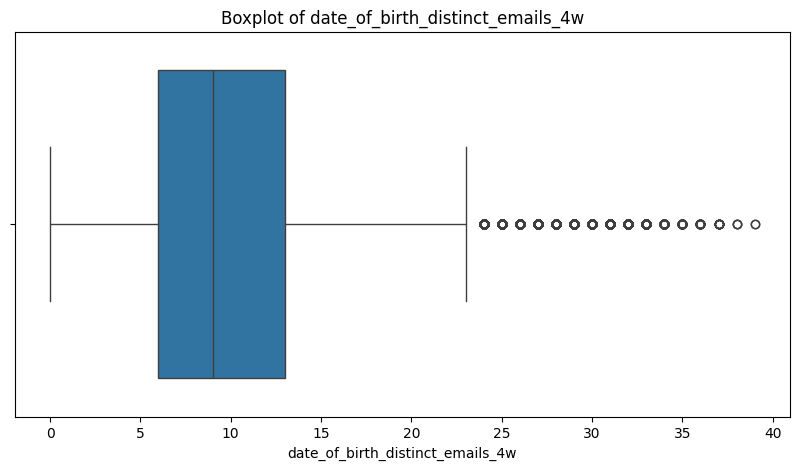

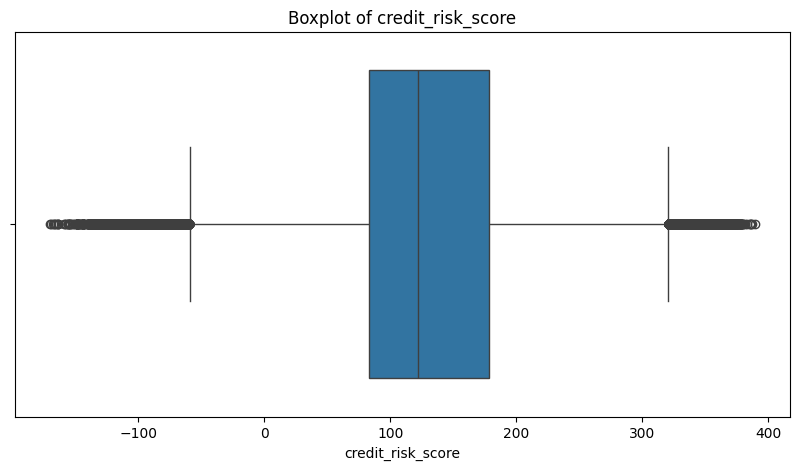

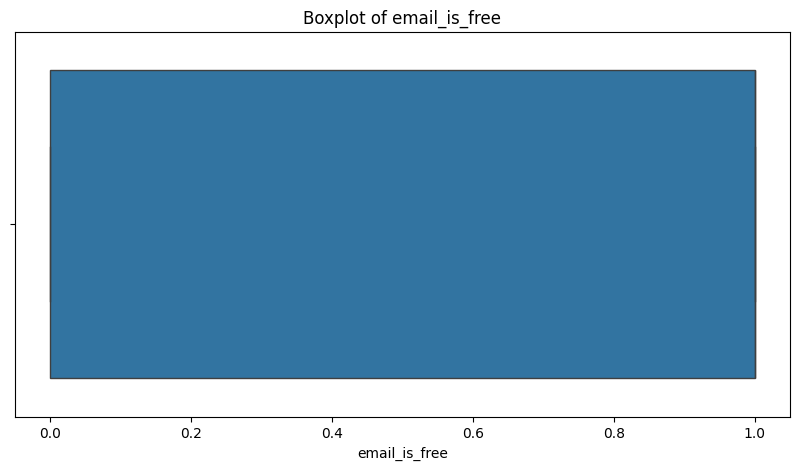

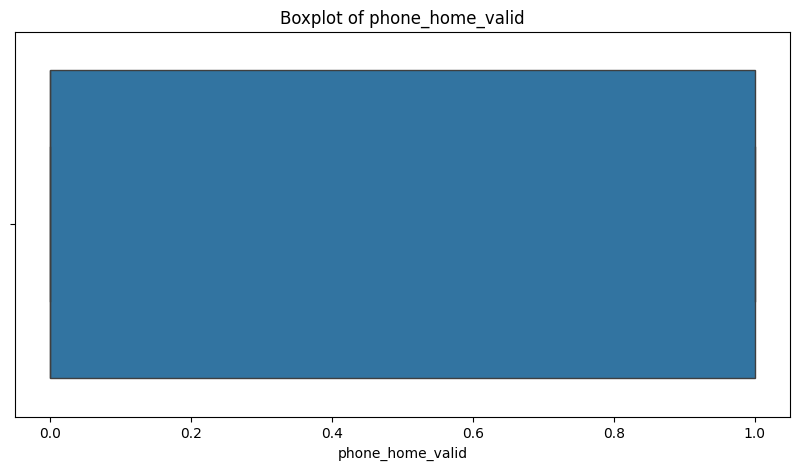

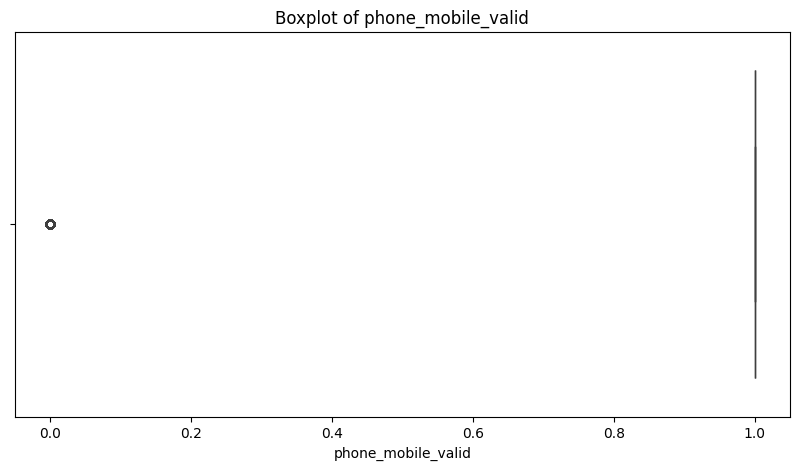

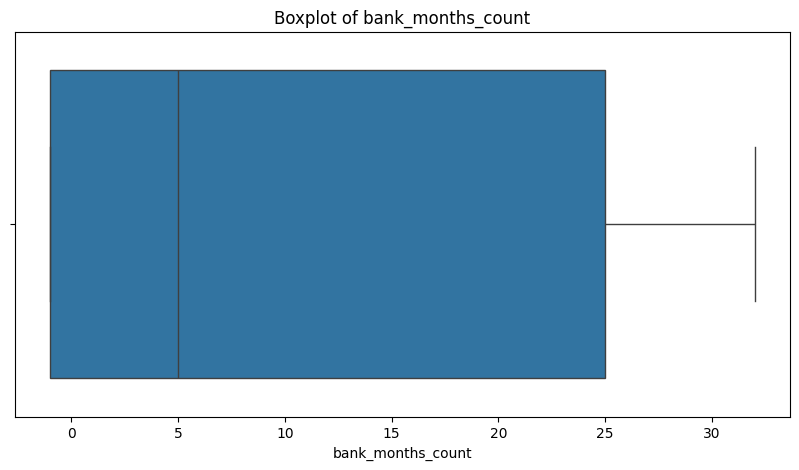

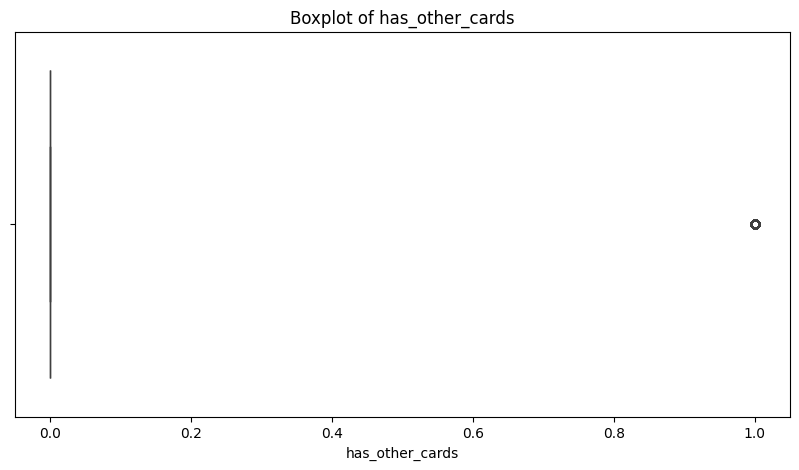

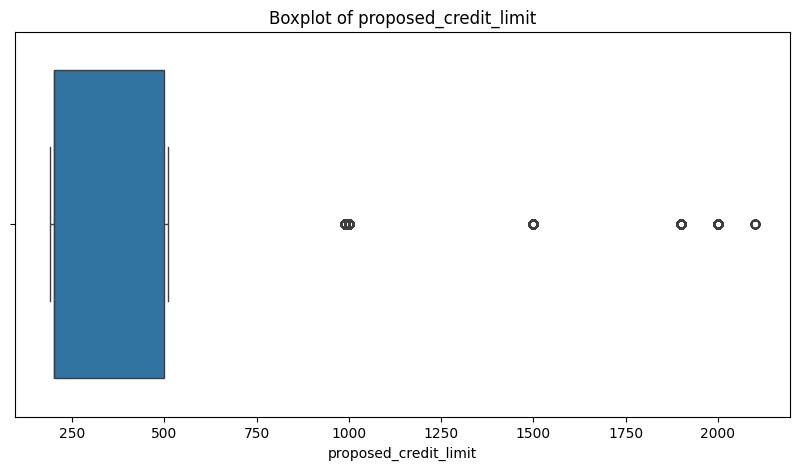

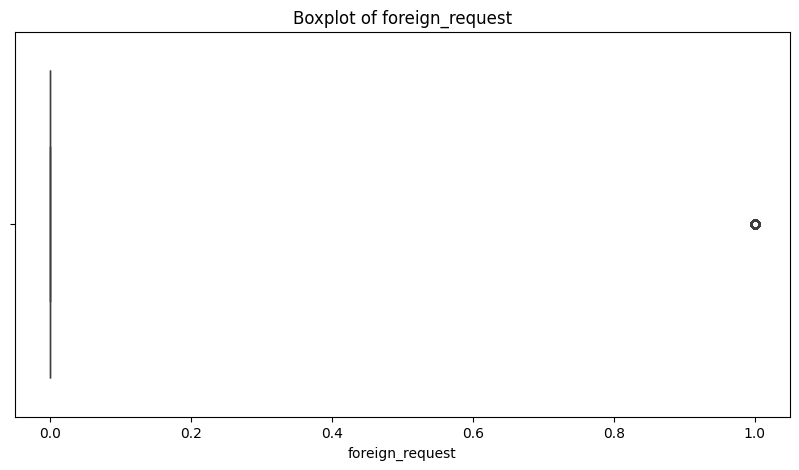

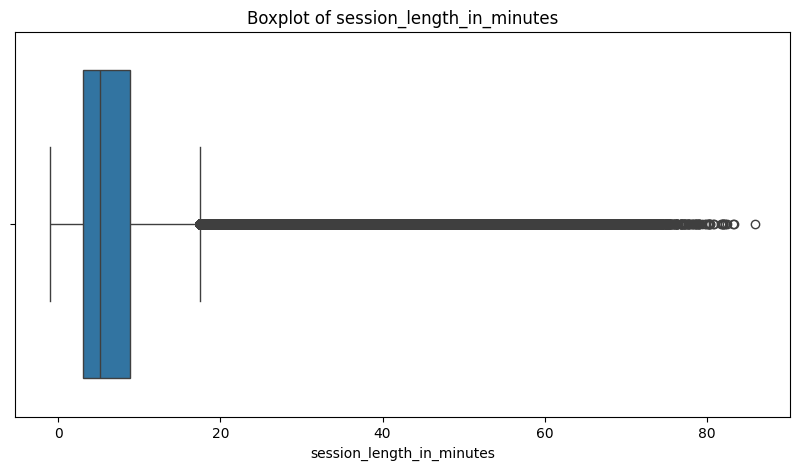

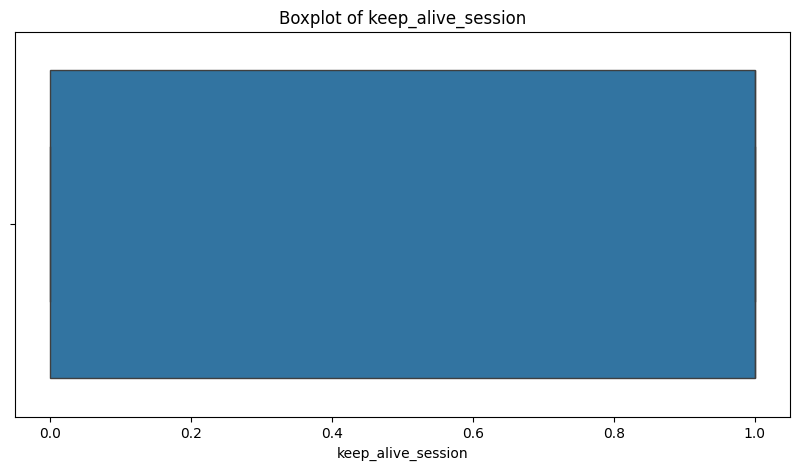

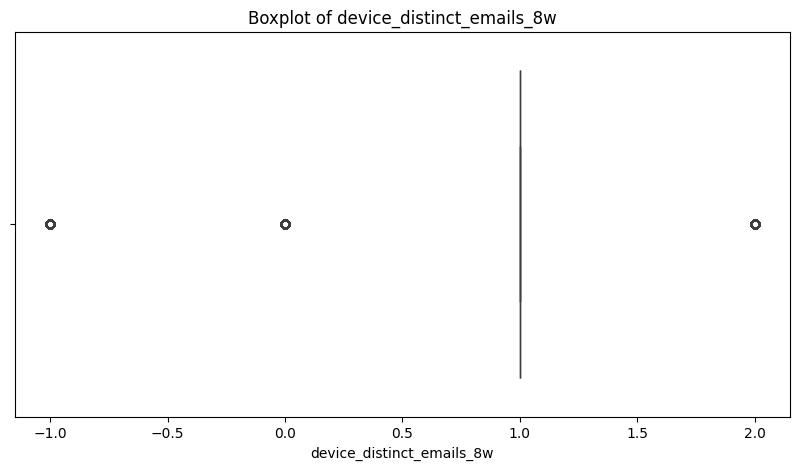

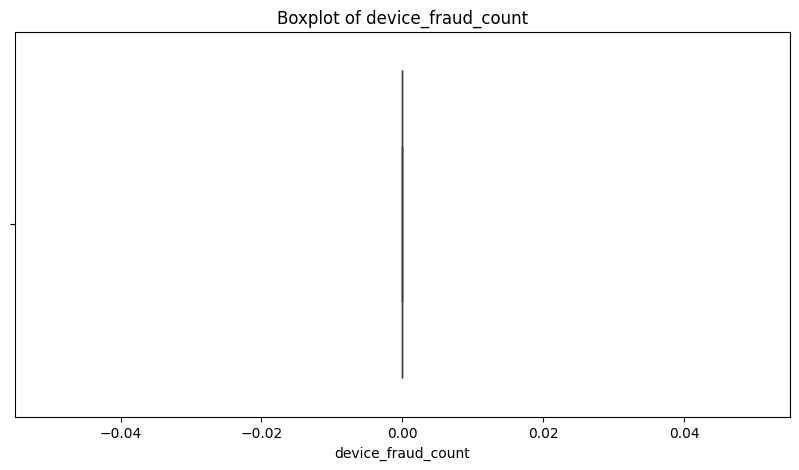

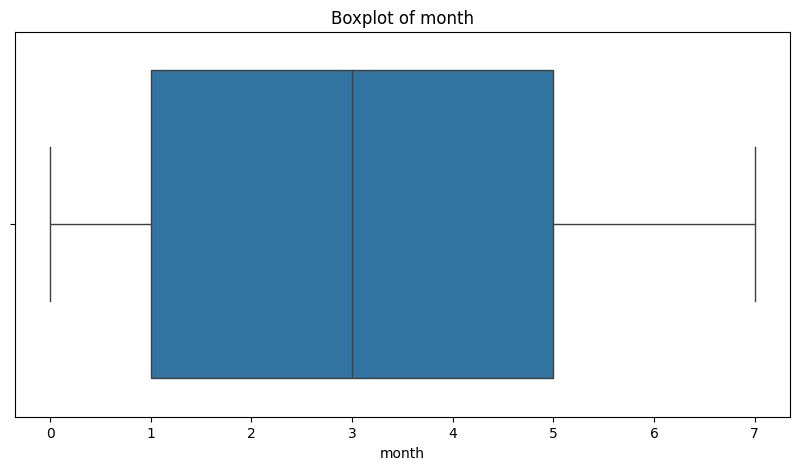

In [ ]:
# check outliers in numeric columns (need to fix)
# for col in num_cols:
#     plt.figure(figsize=(10, 5))
#     sns.boxplot(x=df[col])
#     plt.title(f'Boxplot of {col}')
#     plt.show()

## Target & imbalance

In [13]:

TARGET = "fraud_bool"
counts = df[TARGET].value_counts().sort_index()          
rates  = df[TARGET].value_counts(normalize=True).sort_index()

fraud_rate     = rates.get(1, 0)
imbalance_ratio = counts.get(0, 0) / counts.get(1, 1)    

summary = pd.DataFrame({
    "count": counts,
    "percent": (rates * 100).round(3),
}).rename(index={0: "legit", 1: "fraud"})

print(summary)
print(f"\nFraud rate     : {fraud_rate:.4%}")
print(f"Imbalance ratio: {imbalance_ratio:,.1f} : 1  (legit : fraud)")


             count  percent
fraud_bool                 
legit       988971   98.897
fraud        11029    1.103

Fraud rate     : 1.1029%
Imbalance ratio: 89.7 : 1  (legit : fraud)


heavy imbalance dataset -> SMOTE? and metrics x-accuracy focus on precision and recall?

In [24]:
print("Columns with NaN:", df.isnull().sum().loc[lambda s: s > 0].to_dict() or "none")


Columns with NaN: none


In [25]:
# Only meaningful for numeric columns; -1 is missing 
num_cols = df.select_dtypes("number").columns.drop(TARGET, errors="ignore")

neg1 = (df[num_cols] == -1).sum()
neg1 = neg1[neg1 > 0].sort_values(ascending=False)

sentinel = pd.DataFrame({
    "neg1_count": neg1,
    "neg1_pct": (neg1 / len(df) * 100).round(2),
})
print("Columns using -1 as a missing sentinel:\n", sentinel)


Columns using -1 as a missing sentinel:
                               neg1_count  neg1_pct
prev_address_months_count         712920     71.29
bank_months_count                 253635     25.36
current_address_months_count        4254      0.43
session_length_in_minutes           2015      0.20
credit_risk_score                    488      0.05
device_distinct_emails_8w            359      0.04


In [27]:
nunique = df.nunique().sort_values()
top_share = df.apply(lambda c: c.value_counts(normalize=True).iloc[0])  

quality = pd.DataFrame({
    "n_unique": nunique,
    "dominant_value_pct": (top_share * 100).round(2),
}).sort_values("n_unique")

print("Low-variance columns (candidates to drop):")
print(quality[(quality["n_unique"] <= 1) | (quality["dominant_value_pct"] >= 99)])


Low-variance columns (candidates to drop):
                    n_unique  dominant_value_pct
device_fraud_count         1               100.0
source                     2                99.3


should drop device fraud count? 

### Should we drop source?

source
INTERNET    89.954658
TELEAPP     61.928571
Name: count, dtype: float64

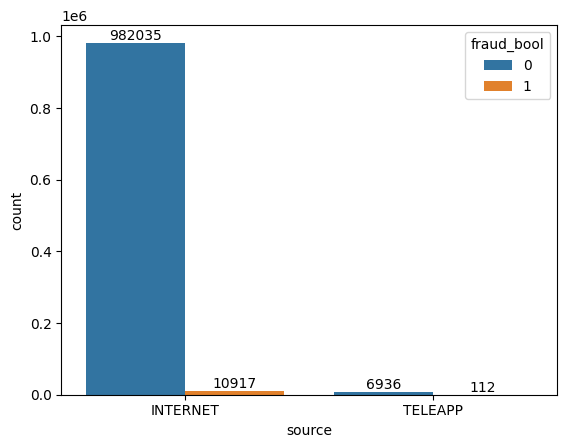

In [40]:
# plot between fraud and legit source distribution 
ax = sns.countplot(data=df, x='source', hue=TARGET, stat='count')
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='edge')
ax.bar_label(ax.containers[1], fmt='%.0f', label_type='edge')

ratio = df[df[TARGET] == 0]['source'].value_counts() / df[df[TARGET] == 1]['source'].value_counts()
ratio

No we gonna keep source 

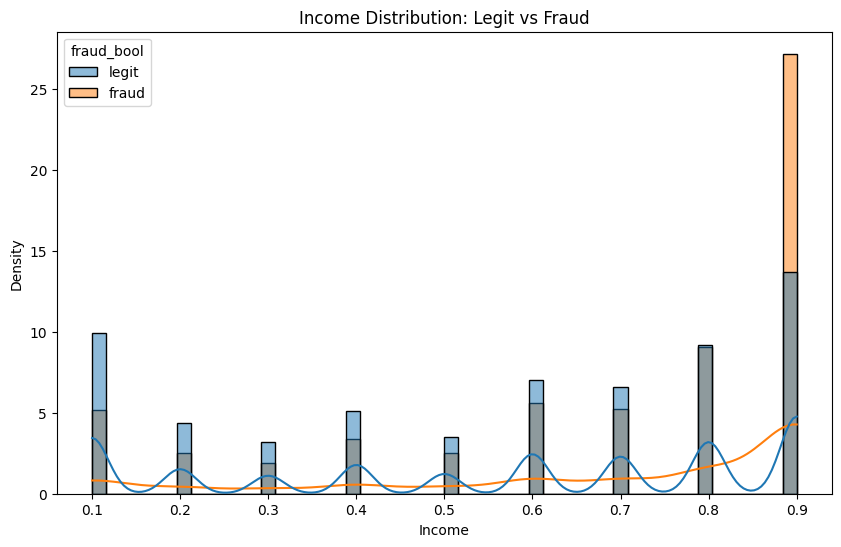

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="income",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="density",
    common_norm=False,
    bins=50,
    kde=True,
    alpha=0.5
)
plt.title("Income Distribution: Legit vs Fraud")
plt.xlabel("Income")
plt.ylabel("Density")
plt.show()
    

most of fraud transaction have high density

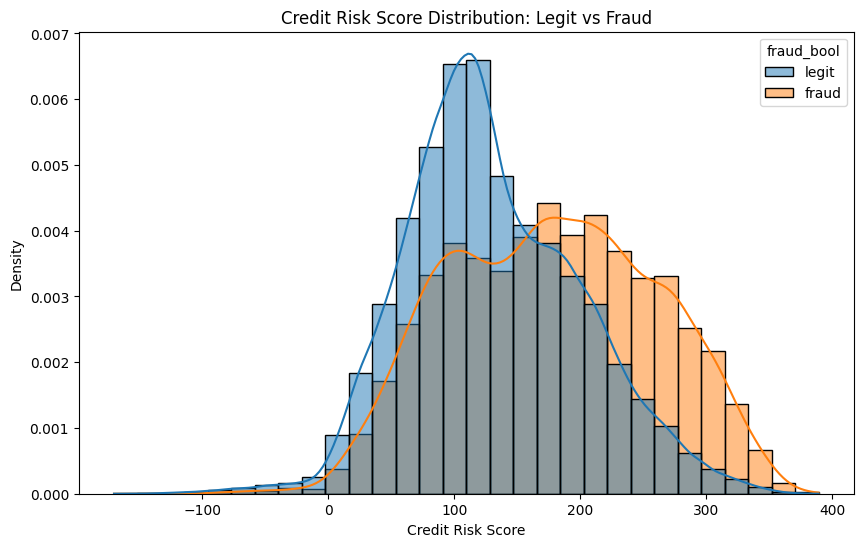

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="credit_risk_score",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="density",
    common_norm=False,
    bins=30,
    kde=True,
    alpha=0.5
)
plt.title("Credit Risk Score Distribution: Legit vs Fraud")
plt.xlabel("Credit Risk Score")
plt.ylabel("Density")
plt.show()


customer_age
10    282.608108
20    203.029046
30    119.290846
40     82.001391
50     49.036720
60     29.261097
70     23.779468
80     19.265625
90     18.000000
Name: count, dtype: float64

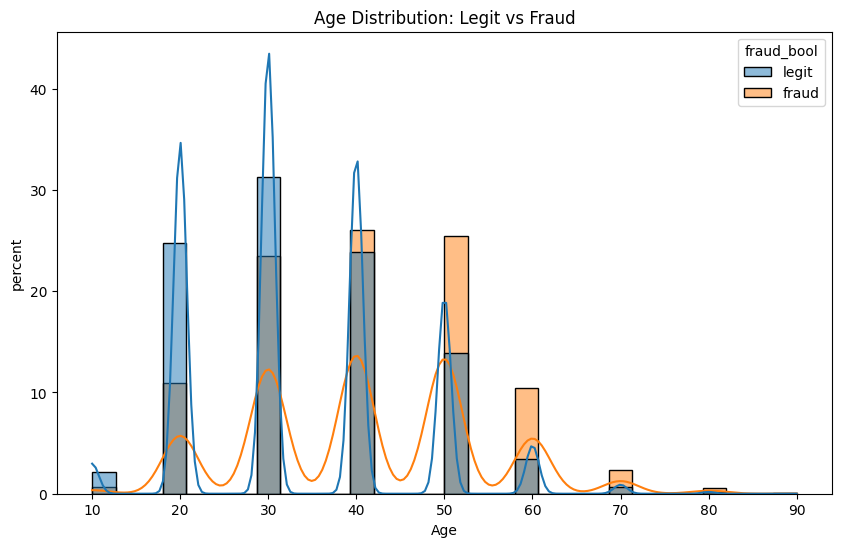

In [62]:
#distribution of fraud and legit customer age distribution
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x="customer_age",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="percent",
    common_norm=False,
    bins=30,
    kde=True,
    alpha=0.5,

)
plt.title("Age Distribution: Legit vs Fraud")
plt.xlabel("Age")
plt.ylabel("percent")

ratio = df[df[TARGET] == 0]['customer_age'].value_counts() / df[df[TARGET] == 1]['customer_age'].value_counts()
ratio

                        total  fraud   legit  fraud_rate  legit_to_fraud_ratio
name_email_similarity                                                         
0.0-0.1                 90360   1872   88488    0.020717             47.269231
0.1-0.2                130685   2342  128343    0.017921             54.800598
0.2-0.3                105271   1399  103872    0.013290             74.247320
0.3-0.4                 81944    805   81139    0.009824            100.793789
0.4-0.5                100800    705  100095    0.006994            141.978723
0.5-0.6                101219    702  100517    0.006935            143.186610
0.6-0.7                 83226    618   82608    0.007426            133.669903
0.7-0.8                101579   1005  100574    0.009894            100.073632
0.8-0.9                133087   1104  131983    0.008295            119.549819
0.9-1.0                 71829    477   71352    0.006641            149.584906


/var/folders/0w/dg96nhvx2qdd7h5pk8ft6mhh0000gn/T/ipykernel_84456/1488042508.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


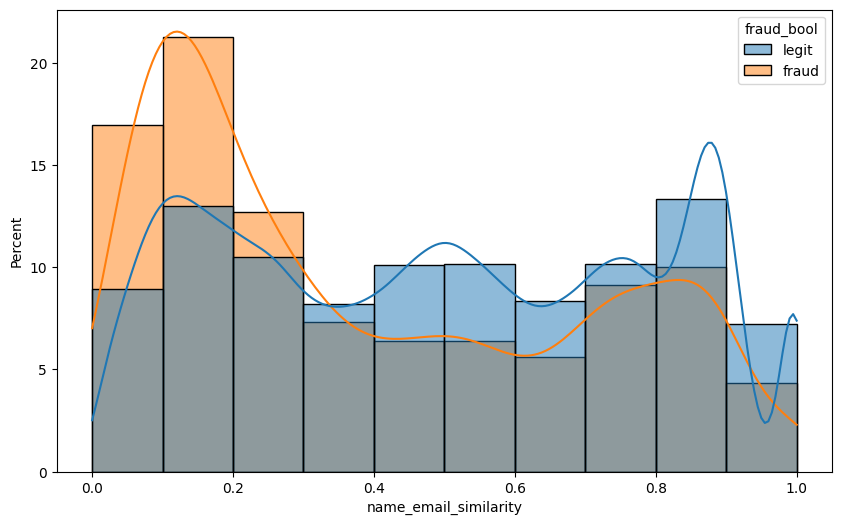

In [60]:
# plot distribution of fraud vs legit on name-email-similarity
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="name_email_similarity",
    hue=df[TARGET].map({0: "legit", 1: "fraud"}),
    stat="percent",
    common_norm=False,
    bins=10,
    kde=True,
    alpha=0.5,

)
bins = np.linspace(0, 1, 11)
labels = [f"{i/10:.1f}-{(i+1)/10:.1f}" for i in range(10)]

ratio_df = (
    df.groupby(
        pd.cut(
            df["name_email_similarity"],
            bins=bins,
            labels=labels,
            include_lowest=True,
        )
    )[TARGET]
    .agg(total="size", fraud="sum")
    .assign(
        legit=lambda x: x["total"] - x["fraud"],
        fraud_rate=lambda x: x["fraud"] / x["total"],
        legit_to_fraud_ratio=lambda x: x["legit"] / x["fraud"].replace(0, np.nan),
    )
)

print(ratio_df)



payment_type
AA    188.332111
AB     87.883185
AC     58.888572
AD     91.408243
AE    288.000000
Name: count, dtype: float64

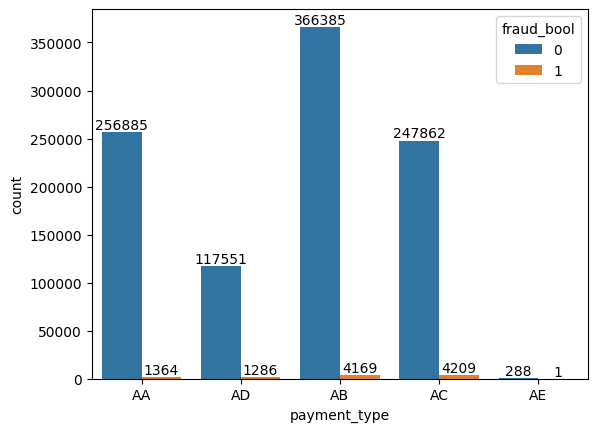

In [ ]:
# plot between fraud and legit source distribution 
ax = sns.countplot(data=df, x='payment_type', hue=TARGET, stat='count')
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='edge')
ax.bar_label(ax.containers[1], fmt='%.0f', label_type='edge')

ratio = df[df[TARGET] == 0]['payment_type'].value_counts() / df[df[TARGET] == 1]['payment_type'].value_counts()
ratio
# useless????